## Factor Analysis

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Step 0: Read the data
survey = pd.read_csv("/content/Athena_survey_data.csv")
survey

,gender,state,age,income,imp.challenge,imp.unlocks,imp.customize,imp.difficulty,imp.characters,imp.storyline,...,freq.customize,freq.test.world,gg.game.presented,gg.maxprice,rank.WarriorGuild,rank.SeraphGuardians,rank.Evercrest,rank.DevilsGate,rank.Marksman,rank.QuestoftheTitan
0,male,IN,19,20000,4,7,5,7,5,3,...,3,1,Warrior Guild,42.0,2,3,6,4,1,5
1,male,OR,29,80000,5,7,1,4,2,4,...,1,3,Warrior Guild,59.0,3,1,6,4,2,5
2,male,MN,52,91000,4,3,3,4,5,7,...,2,3,Seraph Guardians,74.0,4,1,3,5,6,2
3,female,FL,20,24000,7,3,3,6,5,4,...,2,3,Warrior Guild,38.0,3,1,4,2,5,6
4,female,NM,33,64000,7,6,1,7,1,2,...,1,3,Evercrest,42.0,3,2,5,4,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2173,male,MA,28,54000,5,3,1,5,3,3,...,2,5,Evercrest,44.0,1,2,5,3,4,6
2174,male,NY,42,118000,3,7,3,3,6,3,...,1,1,Evercrest,75.0,6,1,3,5,4,2
2175,female,MO,52,97000,6,5,1,5,3,2,...,2,3,Evercrest,63.0,4,2,6,3,1,5
2176,nonbinary,TX,22,33000,2,4,4,1,2,1,...,2,2,Seraph Guardians,28.0,2,4,6,1,3,5


In [ ]:
pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=ee93ab11c37e9239437780ff4023f2d9e90915ba765b0e6dcf0503b30835e45d
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [ ]:
# Step 1: Evaluate the data
# Bartlett's Test of Sphericity (we want p < 0.05 to go ahead)
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(survey.iloc[:, 4:44])
print(f"Bartlett's Test of Sphericity p-value: {p_value}")

# KMO-test (we want overall MSA > 0.6 to go ahead)
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(survey.iloc[:, 4:44])
print(f"KMO-test overall MSA: {kmo_model}")

Bartlett's Test of Sphericity p-value: 0.0
KMO-test overall MSA: 0.8903064302758804


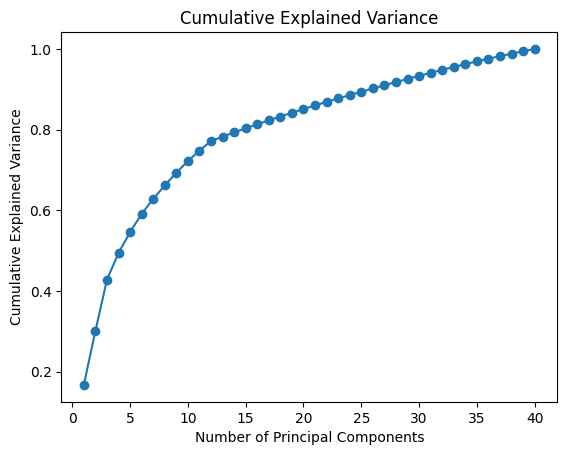

array([6.6930014 , 5.35042033, 5.08654204, 2.63196852, 2.09323499,
       1.79060433, 1.49185008, 1.34244474, 1.26272407, 1.14607329,
       1.04575203, 0.9461203 , 0.43730903, 0.41672851, 0.40923929,
       0.39558531, 0.39151915, 0.37984153, 0.37767606, 0.37204413,
       0.35662305, 0.3502892 , 0.33996429, 0.33292758, 0.32947343,
       0.32751998, 0.32053907, 0.31765556, 0.31178708, 0.30282288,
       0.29923353, 0.29216912, 0.28939193, 0.28204642, 0.2716738 ,
       0.26252222, 0.25701791, 0.24804166, 0.24196581, 0.22403024])

In [ ]:
# Step 2: Determine the number of factors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize the features (important for PCA)
scaler = StandardScaler()
survey_scaled = scaler.fit_transform(survey.iloc[:, 4:44])

# Create and fit the PCA model
pca = PCA()
pca.fit(survey_scaled)

# Get the explained variance ratios
explained_variance_ratios = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_explained_variance = explained_variance_ratios.cumsum()

# Plot the explained variance ratios, want the factors to explain
# very roughly 70% or more of the variance
plt.plot(range(1, len(explained_variance_ratios) + 1), \
         cumulative_explained_variance, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

pca.explained_variance_ # eigenvalues; want values > 1

In [ ]:
#11 factors?

In [ ]:
# Step 3: Extract the factor solution (with varimax rotation)
from factor_analyzer import Rotator
from sklearn.decomposition import FactorAnalysis

rotator = Rotator()

fa = FactorAnalysis(n_components=11)
fa.fit(survey_scaled)
rotated_loading = rotator.fit_transform(fa.components_.T)

print("Rotated Factor Loadings:")
loadings=pd.DataFrame(rotated_loading, columns=['Factor 1', 'Factor 2','Factor 3','Factor 4','Factor 5','Factor 6','Factor 7','Factor 8','Factor 9','Factor 10','Factor 11'], index=survey.columns[4:44])
loadings

Rotated Factor Loadings:


,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11
imp.challenge,0.425072,0.007491,0.053897,-0.148200,-0.144482,0.000137,0.087881,0.023573,-0.027669,-0.001777,-0.677377
imp.unlocks,-0.103044,-0.759033,0.088499,-0.135689,0.070300,0.161542,0.000928,0.235759,-0.009678,-0.160529,0.014067
imp.customize,0.002733,-0.011961,-0.096394,-0.096246,-0.114603,-0.005573,-0.220559,-0.022567,0.763657,0.052034,0.031715
imp.difficulty,0.418318,-0.003551,0.080251,-0.136887,-0.137690,0.012850,0.081119,0.020505,-0.031947,0.008110,-0.683742
imp.characters,-0.024772,0.074043,-0.778673,0.044022,-0.077009,-0.030777,-0.308535,0.012829,0.102793,-0.044168,0.032034
imp.storyline,-0.000631,0.079965,-0.760563,0.056150,-0.087919,-0.050181,-0.325084,0.005224,0.131192,-0.070509,0.045702
imp.mastery,0.669933,0.031975,0.037462,-0.113611,-0.167583,-0.017152,0.031774,-0.012753,-0.007764,-0.011835,-0.419271
imp.backstory,-0.029901,0.068085,-0.786485,0.042888,-0.078010,-0.008450,-0.306317,0.000217,0.115964,-0.060089,0.044303
imp.dominate,-0.023356,0.120203,0.049777,0.041391,-0.068661,-0.154191,0.011882,-0.166063,0.057819,0.699448,-0.036650
imp.completion,-0.106218,-0.797111,0.053616,-0.120769,0.070044,0.140648,0.021588,0.209009,0.003189,-0.148145,-0.000087


In [ ]:
# Or use this loop to print specific strong loadings clearly
print("\n--- Strong Loadings (Abs > 0.4) ---")
for col in loadings.columns:
    print(f"\n{col}:")
    sorted_series = loadings[col].abs().sort_values(ascending=False)
    for var in sorted_series.index:
        val = loadings.loc[var, col]
        if abs(val) > 0.4:
            print(f"  {var}: {val:.3f}")


--- Strong Loadings (Abs > 0.4) ---

Factor 1:
  enj.decisions: 0.825
  enj.strategy: 0.806
  enj.planning: 0.794
  imp.mastery: 0.670
  freq.study: 0.662
  imp.challenge: 0.425
  imp.difficulty: 0.418

Factor 2:
  imp.completion: -0.797
  imp.collect: -0.794
  imp.unlocks: -0.759

Factor 3:
  imp.backstory: -0.786
  imp.characters: -0.779
  imp.storyline: -0.761

Factor 4:
  enj.guns: 0.797
  enj.blow.up: 0.796
  enj.gore: 0.794
  enj.destruction: 0.788

Factor 5:
  imp.offbeat: -0.790
  freq.experiment: -0.779
  freq.explore: -0.772
  freq.test.world: -0.771

Factor 6:
  enj.fast: -0.752
  enj.excitement: -0.743
  enj.react: -0.719

Factor 7:
  imp.fantasy: -0.782
  enj.roleplay: -0.781
  enj.immersion: -0.779
  imp.power: -0.771
  imp.items: -0.715

Factor 8:
  enj.helping: -0.787
  enj.common.goal: -0.781
  enj.others: -0.701

Factor 9:
  imp.customize: 0.764
  freq.customize: 0.739
  freq.char.creation: 0.730

Factor 10:
  enj.competition: 0.762
  enj.duels: 0.751
  imp.dominate:

In [ ]:
# Step 4: Create and name the factor scores
factor_scores = fa.transform(survey_scaled)
survey['Factor 1'] = factor_scores[:, 0]
survey['Factor 2'] = factor_scores[:, 1]
survey['Factor 3'] = factor_scores[:, 2]
survey['Factor 4'] = factor_scores[:, 3]
survey['Factor 5'] = factor_scores[:, 4]
survey['Factor 6'] = factor_scores[:, 5]
survey['Factor 7'] = factor_scores[:, 6]
survey['Factor 8'] = factor_scores[:, 7]
survey['Factor 9'] = factor_scores[:, 8]
survey['Factor 10'] = factor_scores[:, 9]
survey['Factor 11'] = factor_scores[:, 10]

survey

,gender,state,age,income,imp.challenge,imp.unlocks,imp.customize,imp.difficulty,imp.characters,imp.storyline,...,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11
0,male,IN,19,20000,4,7,5,7,5,3,...,-1.069365,0.304991,-1.736799,-0.005785,-0.998547,1.045851,-0.786105,-0.890018,-0.031550,-1.622037
1,male,OR,29,80000,5,7,1,4,2,4,...,-0.321623,0.417804,0.345072,-1.888753,-0.112307,-1.411236,-0.065405,-1.469777,0.520904,0.303790
2,male,MN,52,91000,4,3,3,4,5,7,...,-0.611355,-1.339602,0.250252,0.959893,1.382249,-1.215634,-0.163678,0.108735,-0.074610,-0.662534
3,female,FL,20,24000,7,3,3,6,5,4,...,0.371747,1.673307,-0.586875,1.381628,-0.195424,-1.306300,-0.633214,-0.644074,0.975141,0.815366
4,female,NM,33,64000,7,6,1,7,1,2,...,-1.062189,1.999858,0.793975,-0.017496,-0.526162,-1.174895,-0.113353,0.028005,-0.375355,-0.861562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2173,male,MA,28,54000,5,3,1,5,3,3,...,-0.032388,1.399148,-0.765368,0.053153,1.853163,1.018910,0.363882,-1.096099,-0.424239,-0.375751
2174,male,NY,42,118000,3,7,3,3,6,3,...,-2.000734,-0.151384,-0.577538,1.195290,0.543921,0.059723,-0.074856,-0.772996,-0.528863,0.729306
2175,female,MO,52,97000,6,5,1,5,3,2,...,-0.721416,1.853729,0.868332,-0.286732,1.124193,0.374876,0.984215,0.387760,0.348958,0.087454
2176,nonbinary,TX,22,33000,2,4,4,1,2,1,...,1.391650,0.705834,-0.690848,-0.563138,-0.577827,-0.748499,0.496216,1.069095,-0.058206,1.500282


##Cluster Analysis

/tmp/ipython-input-252/2718093.py:8: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  hc = linkage(dissimilarity_matrix, method="ward")


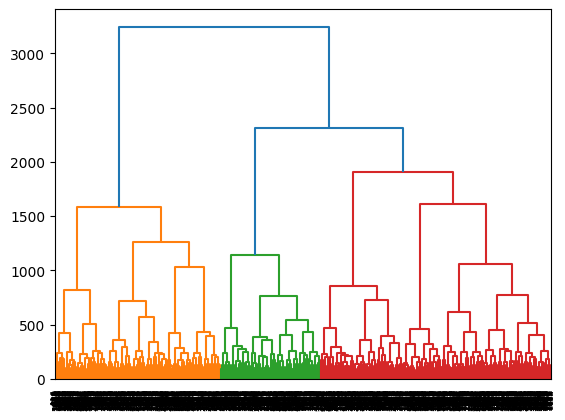

In [ ]:
# Step 1: determine the number of clusters
# Option A: dendogram
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
dissimilarity_matrix = squareform(pdist(survey.iloc[:, 4:44], metric='euclidean'))

# perform hierarchical clustering using Ward's method on this matrix
hc = linkage(dissimilarity_matrix, method="ward")

# plot the resulting dendrogram
dendrogram(hc, leaf_font_size=6)
plt.show()

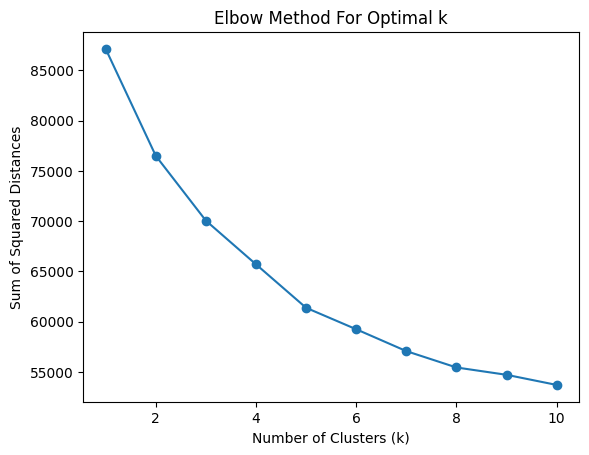

In [ ]:
# Option B: The Elbow
from sklearn.cluster import KMeans

# Calculate the sum of squared distances for different values of k
sum_of_squared_distances = []
K_range = range(1, 11)  # You can adjust this range based on your problem
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto')
    kmeans.fit(survey_scaled)
    sum_of_squared_distances.append(kmeans.inertia_)

# Plot the Elbow curve
plt.plot(K_range, sum_of_squared_distances, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import statsmodels.api as sm

In [ ]:
from sklearn.metrics import silhouette_score


K	Inertia		Silhouette
2	76484.65		0.117
3	69792.81		0.111
4	64990.58		0.111
5	61374.16		0.112
6	59194.80		0.112
7	57066.32		0.111
8	55440.01		0.106
9	54376.63		0.102
10	53697.06		0.099


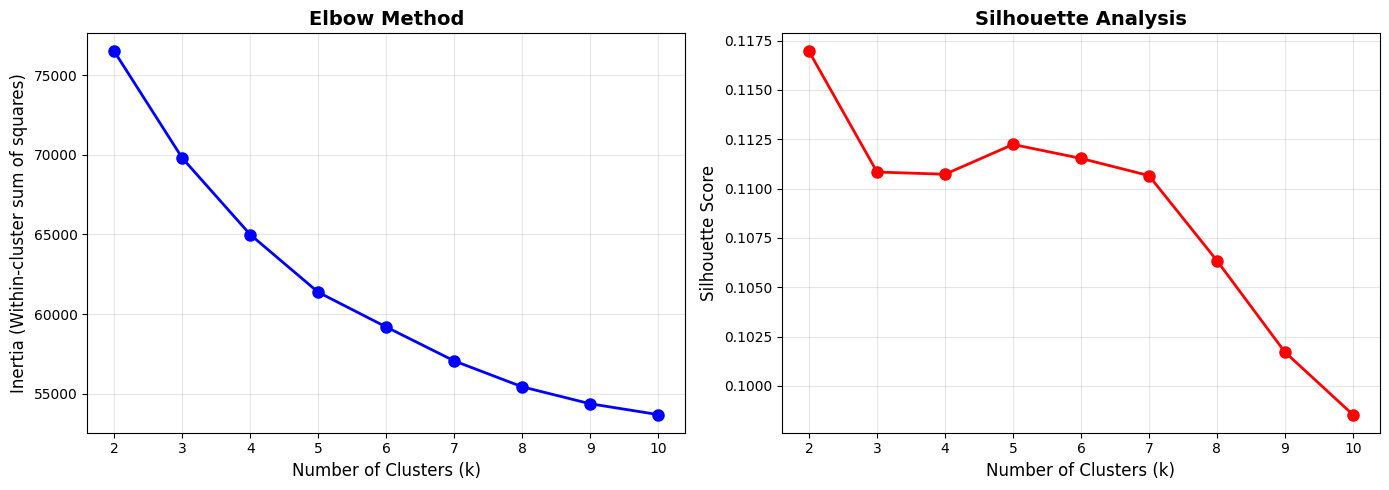

In [ ]:
# Elbow method and Silhouette analysis
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(survey_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(survey_scaled, kmeans.labels_))

print("K\tInertia\t\tSilhouette")
for i, k in enumerate(k_range):
    print(f"{k}\t{inertias[i]:.2f}\t\t{silhouette_scores[i]:.3f}")

# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




##K=5


In [ ]:
# Step 2: Calculate the final cluster solution
kmeans = KMeans(n_clusters=5, random_state=11, n_init='auto')

# Add a new column with cluster assignment for each person
survey['Cluster'] = kmeans.fit_predict(survey.iloc[:, 4:44])
survey

,gender,state,age,income,imp.challenge,imp.unlocks,imp.customize,imp.difficulty,imp.characters,imp.storyline,...,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Cluster
0,male,IN,19,20000,4,7,5,7,5,3,...,0.304991,-1.736799,-0.005785,-0.998547,1.045851,-0.786105,-0.890018,-0.031550,-1.622037,2
1,male,OR,29,80000,5,7,1,4,2,4,...,0.417804,0.345072,-1.888753,-0.112307,-1.411236,-0.065405,-1.469777,0.520904,0.303790,2
2,male,MN,52,91000,4,3,3,4,5,7,...,-1.339602,0.250252,0.959893,1.382249,-1.215634,-0.163678,0.108735,-0.074610,-0.662534,1
3,female,FL,20,24000,7,3,3,6,5,4,...,1.673307,-0.586875,1.381628,-0.195424,-1.306300,-0.633214,-0.644074,0.975141,0.815366,4
4,female,NM,33,64000,7,6,1,7,1,2,...,1.999858,0.793975,-0.017496,-0.526162,-1.174895,-0.113353,0.028005,-0.375355,-0.861562,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2173,male,MA,28,54000,5,3,1,5,3,3,...,1.399148,-0.765368,0.053153,1.853163,1.018910,0.363882,-1.096099,-0.424239,-0.375751,4
2174,male,NY,42,118000,3,7,3,3,6,3,...,-0.151384,-0.577538,1.195290,0.543921,0.059723,-0.074856,-0.772996,-0.528863,0.729306,2
2175,female,MO,52,97000,6,5,1,5,3,2,...,1.853729,0.868332,-0.286732,1.124193,0.374876,0.984215,0.387760,0.348958,0.087454,4
2176,nonbinary,TX,22,33000,2,4,4,1,2,1,...,0.705834,-0.690848,-0.563138,-0.577827,-0.748499,0.496216,1.069095,-0.058206,1.500282,0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


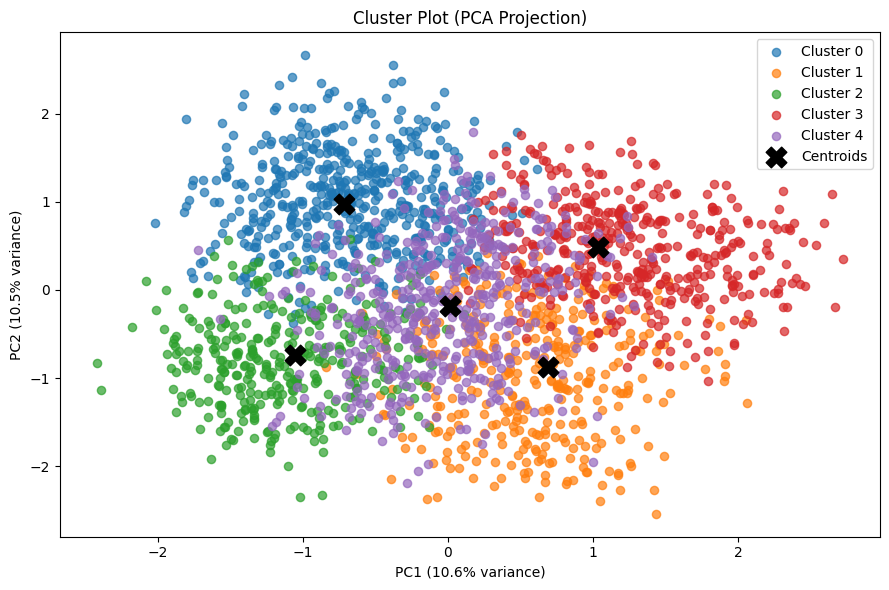

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

survey = survey.copy()

# If you clustered on factor scores, use these
factor_cols = [f'Factor {i}' for i in range(1, 12)]

# If you clustered on the original psychographic items instead,
# replace the line above with this:
# factor_cols = [c for c in survey.columns if c.startswith(('imp.', 'enj.', 'freq.'))]

X = survey[factor_cols].copy()

# If Cluster already exists, use it.
# If not, create it with k=5.
if 'Cluster' not in survey.columns:
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
    survey['Cluster'] = kmeans.fit_predict(X)
else:
    # Refit only so we can plot centroids
    kmeans = KMeans(n_clusters=survey['Cluster'].nunique(), random_state=42, n_init=20)
    kmeans.fit(X)

# Reduce to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plot_df = pd.DataFrame({
    'PC1': X_2d[:, 0],
    'PC2': X_2d[:, 1],
    'Cluster': survey['Cluster']
})

# Project centroids into the same 2D space
centroids_2d = pca.transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(9, 6))

for c in sorted(plot_df['Cluster'].unique()):
    d = plot_df[plot_df['Cluster'] == c]
    plt.scatter(d['PC1'], d['PC2'], s=35, alpha=0.7, label=f'Cluster {c}')

plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    s=220,
    marker='X',
    c='black',
    label='Centroids'
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)')
plt.title('Cluster Plot (PCA Projection)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# KMeasn clustering
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
survey['Cluster'] = kmeans.fit_predict(survey_scaled)



print(f"Cluster Sizes:")
print(survey['Cluster'].value_counts().sort_index())

Cluster Sizes:
Cluster
0    456
1    543
2    345
3    468
4    366
Name: count, dtype: int64


In [ ]:
# Step 3: Interpret the K-means output
print("Cluster Centers:")
p = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=survey.columns[4:44],
    index=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']
)

print(p, "\n")

print("Cluster 0:", p.loc['Cluster 0'].values)
print("Cluster 1:", p.loc['Cluster 1'].values)
print("Cluster 2:", p.loc['Cluster 2'].values)
print("Cluster 3:", p.loc['Cluster 3'].values)
print("Cluster 4:", p.loc['Cluster 4'].values)

Cluster Centers:
           imp.challenge  imp.unlocks  imp.customize  imp.difficulty  \
Cluster 0       0.318239    -0.618142       0.660190        0.273379   
Cluster 1      -0.573212    -0.467038      -0.354380       -0.579995   
Cluster 2      -0.550817     0.985214       0.006527       -0.480735   
Cluster 3       0.844959    -0.044596      -0.625808        0.855205   
Cluster 4      -0.107299     0.591382       0.497289       -0.120507   

           imp.characters  imp.storyline  imp.mastery  imp.backstory  \
Cluster 0        0.605093       0.581383     0.496257       0.594907   
Cluster 1        0.138897       0.145304    -0.615585       0.137531   
Cluster 2       -0.628999      -0.668889    -0.732813      -0.598915   
Cluster 3       -0.825560      -0.819116     0.846521      -0.837868   
Cluster 4        0.688588       0.737984    -0.096671       0.690687   

           imp.dominate  imp.completion  ...  enj.guns  enj.gore  enj.blow.up  \
Cluster 0      0.420413       -0.568

In [ ]:
cluster_profiles = survey.groupby('Cluster')[[f'Factor {i+1}' for i in range(11)]].mean()
print("\nMean Factor Scores by Cluster:")
print(cluster_profiles.round(3))


Mean Factor Scores by Cluster:
         Factor 1  Factor 2  Factor 3  Factor 4  Factor 5  Factor 6  Factor 7  \
Cluster                                                                         
0           1.222     0.428    -0.079    -0.338     0.049     0.144     0.039   
1          -0.671     1.009    -0.361     0.363    -0.110    -0.068     0.013   
2          -1.122    -0.807    -0.224    -0.708     0.025    -0.099     0.030   
3          -0.054    -0.228     1.358     0.156     0.169     0.140    -0.084   
4           0.600    -0.978    -0.890     0.350    -0.138    -0.164     0.011   

         Factor 8  Factor 9  Factor 10  Factor 11  
Cluster                                            
0          -0.273     0.026     -0.061     -0.005  
1           0.025    -0.127      0.033      0.026  
2          -0.132     0.156      0.007     -0.017  
3           0.127    -0.000      0.003     -0.042  
4           0.265     0.010      0.017      0.038  


In [ ]:
#survey['Cluster'] = survey['Cluster'].map(cluster_names)

factor_interpretations = {
    'Factor 1': 'Strategy and Master Planning',
    'Factor 2': 'Task Oriented and Progress Collection',
    'Factor 3': 'Scripted Drama',
    'Factor 4': 'Destruction Shooter Violence',
    'Factor 5': 'Experimental Exploration',
    'Factor 6': 'Reactive Gameplay',
    'Factor 7': 'Fantasy Immersion and Roleplay',
    'Factor 8': 'Multiplayer Team Oriented',
    'Factor 9': 'Customization and Self Expression',
    'Factor 10': 'Competitive',
    'Factor 11': 'Challenge Seeking'
}

for cluster_id in range(optimal_k):
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id}:")# {cluster_names[cluster_id]}")
    print(f"{'='*70}")
    print(f"Size: {(survey['Cluster'] == cluster_id).sum()} customers ({(survey['Cluster'] == cluster_id).sum()/len(survey)*100:.1f}%)")

    cluster_scores = cluster_profiles.loc[cluster_id]

    print("\nTop Factors (Highest Scores):")
    top_factors = cluster_scores.nlargest(3)
    for factor, score in top_factors.items():
        if score > 0.3:
            print(f"  • {factor}: {score:.2f} - {factor_interpretations[factor]}")

    print("\nBottom Factors (Lowest Scores):")
    bottom_factors = cluster_scores.nsmallest(3)
    for factor, score in bottom_factors.items():
        if score < -0.3:
            print(f"  • {factor}: {score:.2f} - {factor_interpretations[factor]}")

    print("\nDemographic Profile:")
    #demo = demo_profiles.loc[cluster_id]
    #print(f"  • Avg Age: {demo['age']:.1f} years")
    #print(f"  • Avg Income: ${demo['income']:.1f}k")
    #print(f"  • Avg Kids: {demo['numkids']:.1f}")
    #print(f"  • Miles/Year: {demo['miles']:.1f}k")
    #print(f"  • % Female: {demo['female']*100:.1f}%")


CLUSTER 0:
Size: 456 customers (20.9%)

Top Factors (Highest Scores):
  • Factor 1: 1.22 - Strategy and Master Planning
  • Factor 2: 0.43 - Task Oriented and Progress Collection

Bottom Factors (Lowest Scores):
  • Factor 4: -0.34 - Destruction Shooter Violence

Demographic Profile:

CLUSTER 1:
Size: 543 customers (24.9%)

Top Factors (Highest Scores):
  • Factor 2: 1.01 - Task Oriented and Progress Collection
  • Factor 4: 0.36 - Destruction Shooter Violence

Bottom Factors (Lowest Scores):
  • Factor 1: -0.67 - Strategy and Master Planning
  • Factor 3: -0.36 - Scripted Drama

Demographic Profile:

CLUSTER 2:
Size: 345 customers (15.8%)

Top Factors (Highest Scores):

Bottom Factors (Lowest Scores):
  • Factor 1: -1.12 - Strategy and Master Planning
  • Factor 2: -0.81 - Task Oriented and Progress Collection
  • Factor 4: -0.71 - Destruction Shooter Violence

Demographic Profile:

CLUSTER 3:
Size: 468 customers (21.5%)

Top Factors (Highest Scores):
  • Factor 3: 1.36 - Scripted Dr

In [ ]:
import pandas as pd
import numpy as np

df = survey.copy()

df['Cluster'] = df['Cluster'].astype(int)
df['female'] = (df['gender'].str.lower() == 'female').astype(int)

profile = df.groupby('Cluster').agg(
    n=('Cluster','size'),
    pct_female=('female','mean'),
    avg_age=('age','mean'),
    avg_income=('income','mean')
)

profile['pct_female'] = (profile['pct_female'] * 100).round(1)
profile['avg_age'] = profile['avg_age'].round(1)
profile['avg_income'] = profile['avg_income'].round(0)

print(profile)

           n  pct_female  avg_age  avg_income
Cluster                                      
0        456        51.1     22.9     36568.0
1        543        35.5     24.2     41834.0
2        345        56.5     28.6     53823.0
3        468        42.1     29.6     59799.0
4        366        50.0     36.3     68940.0


In [ ]:
top_states = (
    df.groupby(['Cluster','state']).size()
    .groupby(level=0)
    .apply(lambda s: (s / s.sum() * 100).sort_values(ascending=False).head(3).round(1))
)

print(top_states)

Cluster  Cluster  state
0        0        CA       11.4
                  TX        8.1
                  FL        6.1
1        1        CA       12.9
                  TX        9.0
                  NY        6.8
2        2        CA       13.0
                  TX        8.1
                  FL        6.4
3        3        CA       11.1
                  TX        8.1
                  NY        6.4
4        4        TX       13.4
                  CA        9.0
                  OH        7.9
dtype: float64


In [ ]:
from scipy.stats import chi2_contingency

ct_gender = pd.crosstab(df['Cluster'], df['gender'])
chi2, p, dof, expected = chi2_contingency(ct_gender)

n = ct_gender.to_numpy().sum()
r, k = ct_gender.shape
cramers_v = np.sqrt((chi2 / n) / (min(r-1, k-1)))

print(ct_gender)
print("Gender vs Cluster: chi2=", round(chi2,2), "p=", p, "Cramer's V=", round(cramers_v,3))

gender   female  male  nonbinary
Cluster                         
0           233   222          1
1           193   347          3
2           195   147          3
3           197   266          5
4           183   180          3
Gender vs Cluster: chi2= 52.39 p= 1.4143888205537774e-08 Cramer's V= 0.11


In [ ]:
state_to_region = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast','RI':'Northeast','VT':'Northeast',
    'NJ':'Northeast','NY':'Northeast','PA':'Northeast',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest','IA':'Midwest','KS':'Midwest',
    'MN':'Midwest','MO':'Midwest','NE':'Midwest','ND':'Midwest','SD':'Midwest',
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South','SC':'South','VA':'South','DC':'South',
    'WV':'South','AL':'South','KY':'South','MS':'South','TN':'South','AR':'South','LA':'South','OK':'South','TX':'South',
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West','UT':'West','WY':'West',
    'AK':'West','CA':'West','HI':'West','OR':'West','WA':'West'
}

df['region'] = df['state'].map(state_to_region).fillna('Other')

ct_region = pd.crosstab(df['Cluster'], df['region'])
chi2, p, dof, expected = chi2_contingency(ct_region)

n = ct_region.to_numpy().sum()
r, k = ct_region.shape
cramers_v = np.sqrt((chi2 / n) / (min(r-1, k-1)))

print(ct_region)
print("Region vs Cluster: chi2=", round(chi2,2), "p=", p, "Cramer's V=", round(cramers_v,3))

region   Midwest  Northeast  South  West
Cluster                                 
0             95         78    165   118
1            100        101    210   132
2             72         55    135    83
3            104         79    176   109
4            101         47    143    75
Region vs Cluster: chi2= 16.85 p= 0.15522857751467398 Cramer's V= 0.051


In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

m_age = smf.ols("age ~ C(Cluster)", data=df).fit()
print(sm.stats.anova_lm(m_age, typ=2))

m_inc = smf.ols("income ~ C(Cluster)", data=df).fit()
print(sm.stats.anova_lm(m_inc, typ=2))

                   sum_sq      df           F         PR(>F)
C(Cluster)   46276.193438     4.0  147.654606  8.263894e-112
Residual    170259.112347  2173.0         NaN            NaN
                  sum_sq      df          F        PR(>F)
C(Cluster)  2.973684e+11     4.0  78.844901  1.563364e-62
Residual    2.048901e+12  2173.0        NaN           NaN


In [ ]:
import pandas as pd

survey = survey.copy()

# Optional safety check
print("Missing before:", survey['gg.maxprice'].isna().sum())

# Compute the median gg.maxprice within each presented game
game_medians = survey.groupby('gg.game.presented')['gg.maxprice'].transform('median')

# Fallback in case any game group had all missing values
overall_median = survey['gg.maxprice'].median()

# Replace missing values directly in the original column
survey['gg.maxprice'] = (
    survey['gg.maxprice']
    .fillna(game_medians)
    .fillna(overall_median)
)

# Check result
print("Missing after:", survey['gg.maxprice'].isna().sum())

# Show the medians that were used
print("\nGame-specific medians used:")
print(
    survey.groupby('gg.game.presented')['gg.maxprice']
    .median()
    .round(2)
)

Missing before: 138
Missing after: 0

Game-specific medians used:
gg.game.presented
Evercrest           43.0
Seraph Guardians    43.0
Warrior Guild       43.0
Name: gg.maxprice, dtype: float64


Warrior Guild ideal price point: $35.0


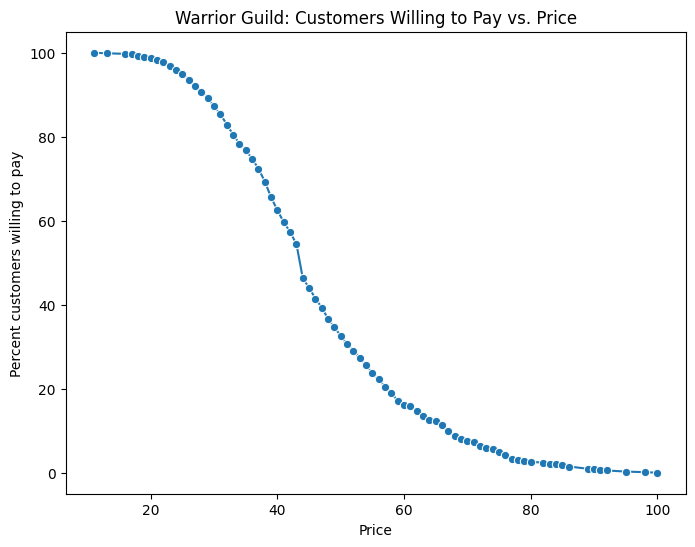

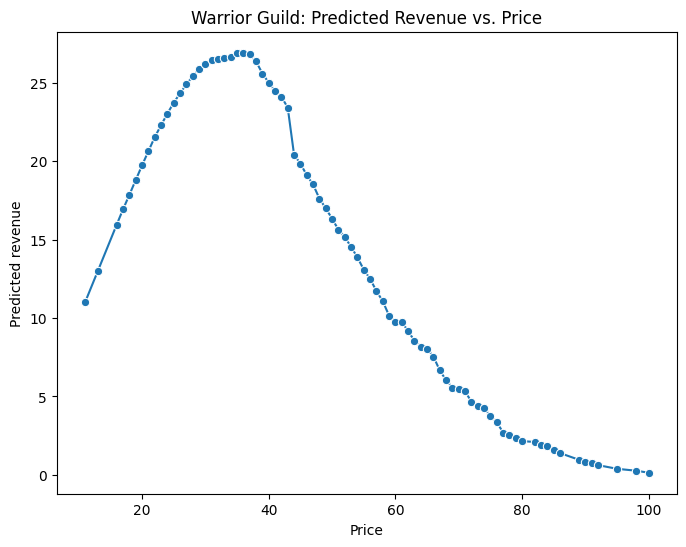

Seraph Guardians ideal price point: $32.0


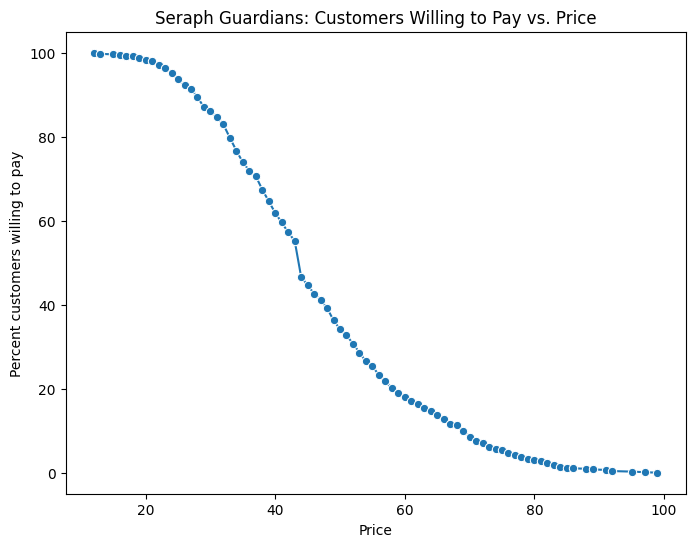

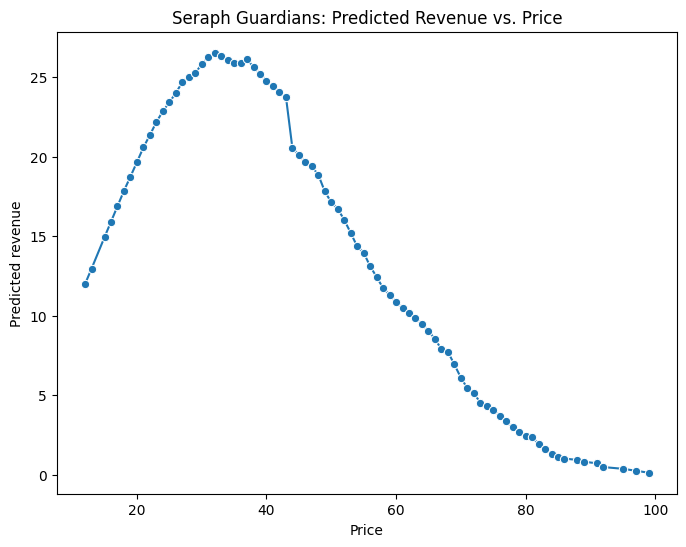

Evercrest ideal price point: $34.0


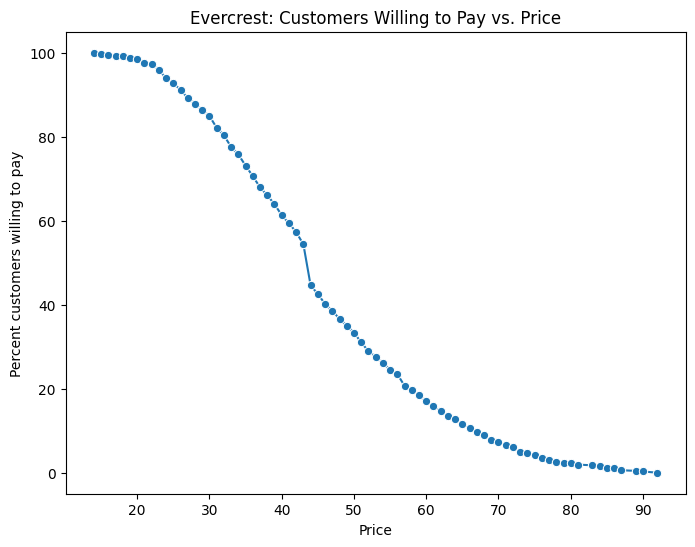

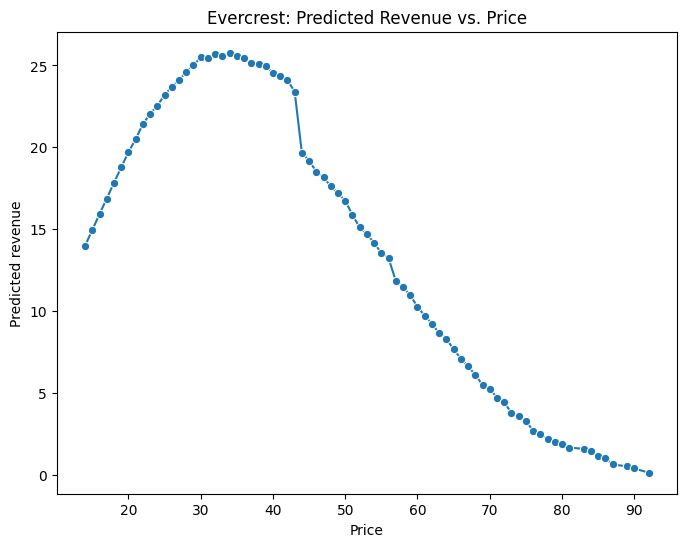

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gabor_granger_for_game(game_name):
    # Filter one game
    game_data = survey[gg['gg.game.presented'] == game_name].copy()

    # Use the unique price points observed for that game
    price_points = sorted(game_data['gg.maxprice'].dropna().unique())

    # Build cumulative willingness-to-pay table
    cumulative_wtp = pd.DataFrame({'price': price_points})
    cumulative_wtp['per_customers_wtp'] = cumulative_wtp['price'].apply(
        lambda p: (game_data['gg.maxprice'] >= p).mean() * 100
    )
    cumulative_wtp['pred_revenue'] = (
        cumulative_wtp['price'] * cumulative_wtp['per_customers_wtp'] / 100
    )

    # Print ideal price
    best_row = cumulative_wtp.loc[cumulative_wtp['pred_revenue'].idxmax()]
    print(f"{game_name} ideal price point: ${best_row['price']}")

    # Plot customers willing to pay
    plt.figure(figsize=(8, 6))
    sns.lineplot(x='price', y='per_customers_wtp', data=cumulative_wtp, marker='o')
    plt.xlabel('Price')
    plt.ylabel('Percent customers willing to pay')
    plt.title(f'{game_name}: Customers Willing to Pay vs. Price')
    plt.show()

    # Plot revenue
    plt.figure(figsize=(8, 6))
    sns.lineplot(x='price', y='pred_revenue', data=cumulative_wtp, marker='o')
    plt.xlabel('Price')
    plt.ylabel('Predicted revenue')
    plt.title(f'{game_name}: Predicted Revenue vs. Price')
    plt.show()

# Run for each game separately
for game in gg['gg.game.presented'].dropna().unique():
    plot_gabor_granger_for_game(game)

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

results = []

for game in survey['gg.game.presented'].dropna().unique():
    temp = survey[
        (survey['gg.game.presented'] == game) &
        (survey['gg.maxprice'].notna())
    ].copy()

    # Linear regression with segment as a categorical predictor
    model = smf.ols('Q("gg.maxprice") ~ C(Cluster)', data=temp).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    # Predicted willingness to pay by segment
    segment_means = temp.groupby('Cluster')['gg.maxprice'].mean().sort_values(ascending=False)

    most_segment = segment_means.idxmax()
    least_segment = segment_means.idxmin()

    results.append({
        'Game': game,
        'Most interested segment': most_segment,
        'Highest avg WTP': round(segment_means.max(), 2),
        'Least interested segment': least_segment,
        'Lowest avg WTP': round(segment_means.min(), 2),
        'Overall p-value': anova_table.loc['C(Cluster)', 'PR(>F)']
    })

    print(f"\n{game}")
    print("Average WTP by segment:")
    print(segment_means.round(2))
    print("\nRegression coefficients:")
    print(model.summary().tables[1])
    print("\nOverall segment effect p-value:", anova_table.loc['C(Cluster)', 'PR(>F)'])

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df)


Warrior Guild
Average WTP by segment:
Cluster
4    51.17
3    47.86
0    44.29
1    42.83
2    41.74
Name: gg.maxprice, dtype: float64

Regression coefficients:
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          44.2941      1.257     35.226      0.000      41.826      46.763
C(Cluster)[T.1]    -1.4660      1.643     -0.892      0.373      -4.692       1.760
C(Cluster)[T.2]    -2.5540      1.809     -1.411      0.159      -6.106       0.998
C(Cluster)[T.3]     3.5684      1.710      2.086      0.037       0.211       6.926
C(Cluster)[T.4]     6.8764      1.802      3.816      0.000       3.338      10.414

Overall segment effect p-value: 1.0546133819583194e-07

Seraph Guardians
Average WTP by segment:
Cluster
4    57.38
3    49.45
2    45.74
0    42.49
1    38.46
Name: gg.maxprice, dtype: float64

Regression coefficients:
                      coef   

In [ ]:
import pandas as pd

survey = survey.copy()

TOTAL_CUSTOMERS = 10_000_000
PURCHASE_RATE = 0.30

fixed_cost = 7_000_000
dev_costs = {
    'Evercrest': 6_000_000,
    'Seraph Guardians': 5_500_000,
    'Warrior Guild': 5_000_000
}

def steam_fee(gross):
    fee = 0

    tier1 = min(gross, 10_000_000)
    fee += 0.30 * tier1

    if gross > 10_000_000:
        tier2 = min(gross, 50_000_000) - 10_000_000
        fee += 0.25 * tier2

    if gross > 50_000_000:
        tier3 = gross - 50_000_000
        fee += 0.20 * tier3

    return fee

results = []

for game in survey['gg.game.presented'].dropna().unique():
    game_data = survey[survey['gg.game.presented'] == game].copy()

    price_points = sorted(game_data['gg.maxprice'].dropna().unique())

    rows = []
    for p in price_points:
        pct_wtp = (game_data['gg.maxprice'] >= p).mean()
        pred_revenue_index = p * pct_wtp
        rows.append([p, pct_wtp, pred_revenue_index])

    cumulative_wtp = pd.DataFrame(rows, columns=['price', 'pct_wtp', 'pred_revenue_index'])

    best_row = cumulative_wtp.loc[cumulative_wtp['pred_revenue_index'].idxmax()]
    ideal_price = best_row['price']
    pct_prob_purchase = best_row['pct_wtp']

    buyers_first_year = TOTAL_CUSTOMERS * pct_prob_purchase * PURCHASE_RATE
    gross_revenue = ideal_price * buyers_first_year

    steam_cut = steam_fee(gross_revenue)
    royalty = 0.05 * gross_revenue

    net_revenue = gross_revenue - steam_cut - royalty
    profit_after_costs = net_revenue - fixed_cost - dev_costs[game]

    results.append({
        'Game': game,
        'Ideal Price': round(ideal_price, 2),
        'Prob Purchase % at Ideal Price': round(pct_prob_purchase * 100, 2),
        'Expected Buyers Year 1': round(buyers_first_year),
        'Gross Revenue': round(gross_revenue, 2),
        'Steam Cut': round(steam_cut, 2),
        'Royalty (5%)': round(royalty, 2),
        'Net Revenue': round(net_revenue, 2),
        'Profit After Fixed + Dev Costs': round(profit_after_costs, 2)
    })

results_df = pd.DataFrame(results)
print(results_df)

               Game  Ideal Price  Prob Purchase % at Ideal Price  \
0     Warrior Guild         35.0                           76.88   
1  Seraph Guardians         32.0                           82.94   
2         Evercrest         34.0                           75.81   

   Expected Buyers Year 1  Gross Revenue    Steam Cut  Royalty (5%)  \
0                 2306452    80725806.45  19145161.29    4036290.32   
1                 2488095    79619047.62  18923809.52    3980952.38   
2                 2274336    77327433.63  18465486.73    3866371.68   

   Net Revenue  Profit After Fixed + Dev Costs  
0  57544354.84                     45544354.84  
1  56714285.71                     44214285.71  
2  54995575.22                     41995575.22  


In [ ]:
print([col for col in survey.columns if 'rank' in col.lower()])

['rank.WarriorGuild', 'rank.SeraphGuardians', 'rank.Evercrest', 'rank.DevilsGate', 'rank.Marksman', 'rank.QuestoftheTitan']


In [ ]:
rank_cols_all = ['rank.WarriorGuild', 'rank.SeraphGuardians', 'rank.Evercrest',
                 'rank.DevilsGate', 'rank.Marksman', 'rank.QuestoftheTitan']

competitors = ['rank.DevilsGate', 'rank.Marksman', 'rank.QuestoftheTitan']
games = ['rank.WarriorGuild', 'rank.SeraphGuardians', 'rank.Evercrest']

scenarios = {
    'Warrior Guild':      games + competitors,
    'Seraph Guardians':   games + competitors,
    'Evercrest':          games + competitors,
}

for game_name, available_cols in scenarios.items():
    # Among only available games, find each respondent's top choice
    top_choice = survey[available_cols].idxmin(axis=1)
    share = top_choice.value_counts(normalize=True) * 100
    athena_col = [c for c in available_cols if c not in competitors][0]
    athena_share = share.get(athena_col, 0)
    print(f"If Athena acquires {game_name}: Athena market share = {athena_share:.2f}%")
    print(share.round(2))
    print()

If Athena acquires Warrior Guild: Athena market share = 13.18%
rank.SeraphGuardians    50.05
rank.DevilsGate         18.60
rank.WarriorGuild       13.18
rank.Evercrest           9.78
rank.QuestoftheTitan     6.11
rank.Marksman            2.30
Name: proportion, dtype: float64

If Athena acquires Seraph Guardians: Athena market share = 13.18%
rank.SeraphGuardians    50.05
rank.DevilsGate         18.60
rank.WarriorGuild       13.18
rank.Evercrest           9.78
rank.QuestoftheTitan     6.11
rank.Marksman            2.30
Name: proportion, dtype: float64

If Athena acquires Evercrest: Athena market share = 13.18%
rank.SeraphGuardians    50.05
rank.DevilsGate         18.60
rank.WarriorGuild       13.18
rank.Evercrest           9.78
rank.QuestoftheTitan     6.11
rank.Marksman            2.30
Name: proportion, dtype: float64

